# Lab 2 - Intro to...

Authors: Khanh Do, Hridi Ghosh

## Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# Suppress FutureWarnings from packages
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  

ic_homes = pd.read_csv("https://remiller1450.github.io/data/IowaCityHomeSales.csv")
ic_homes.head(3)

from sklearn.model_selection import train_test_split
ic_train, ic_test = train_test_split(ic_homes, test_size=0.2, random_state=7)

## Question 1

### Part A

In [8]:
ic_train.isna().sum()

sale.amount       0
sale.date         0
occupancy         0
style             0
built             0
bedrooms          0
bsmt            145
ac                0
attic           578
area.base         0
area.add          0
area.bsmt         0
area.garage1      0
area.garage2      0
area.living       0
area.lot          0
lon               0
lat               0
assessed          0
dtype: int64

In [9]:
ic_train = ic_train.drop(columns=['bsmt', 'attic'])

### Part B

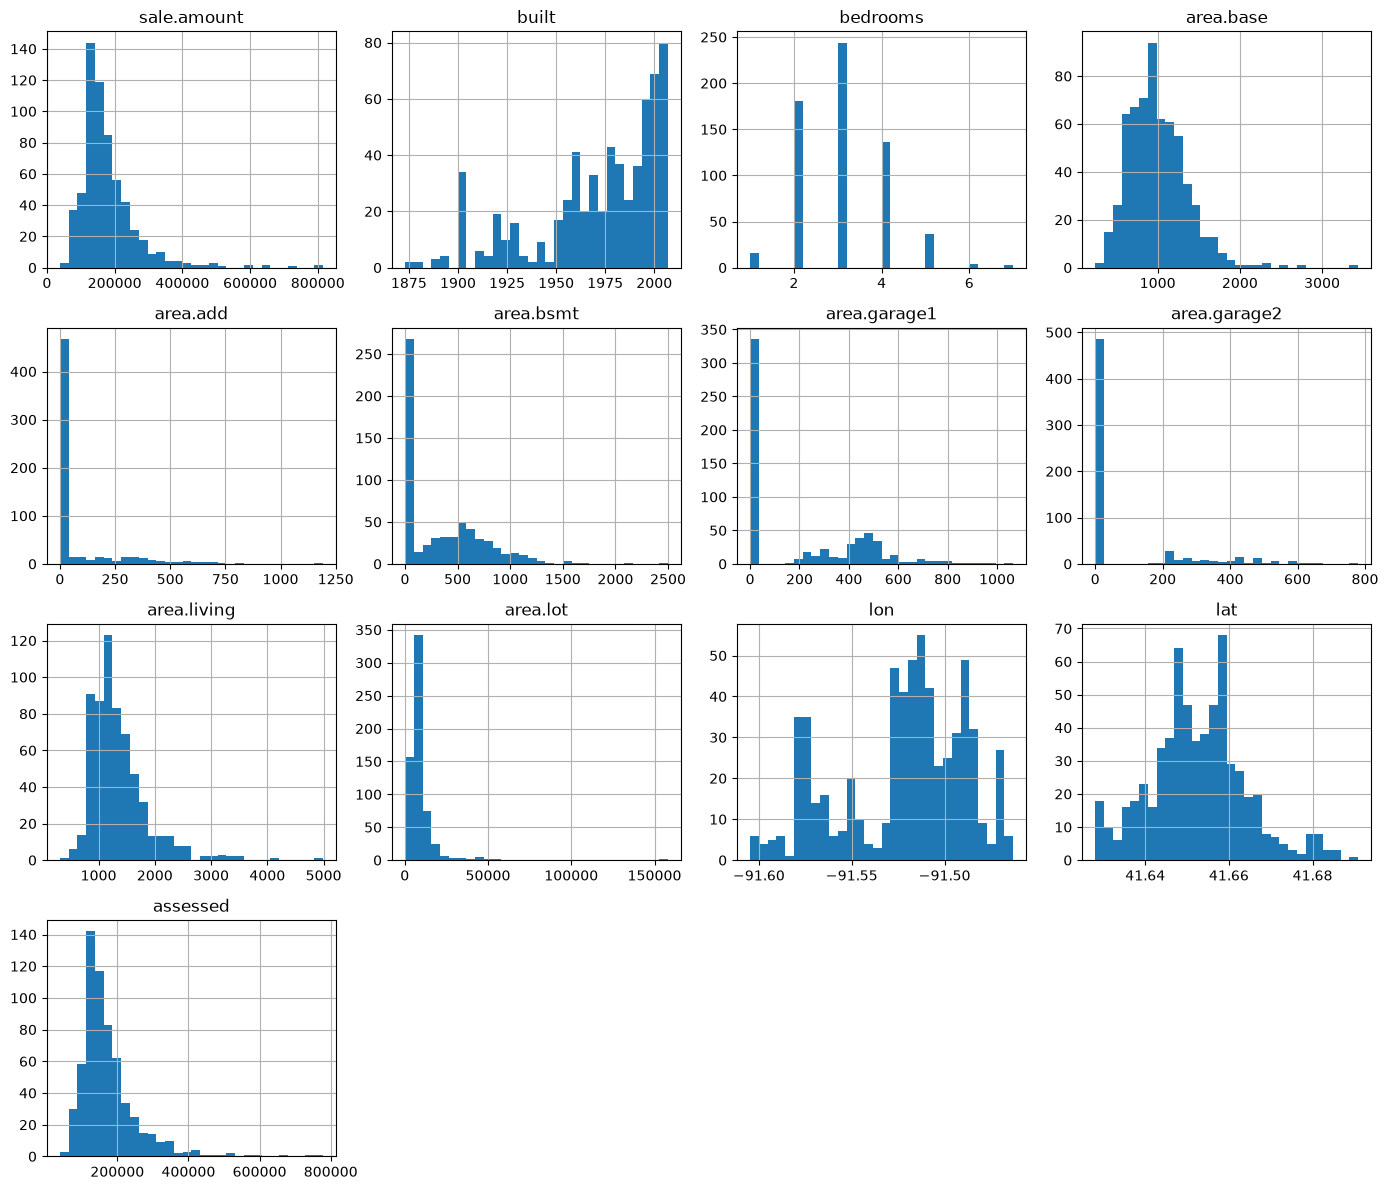

In [10]:
ic_train.hist(figsize=(14,12), bins = 30)
plt.tight_layout()
plt.show()

**Comment:** Most variables (except `lon` and `lat`) looks right-skewed. Some of them have lots of 0s.

### Part C

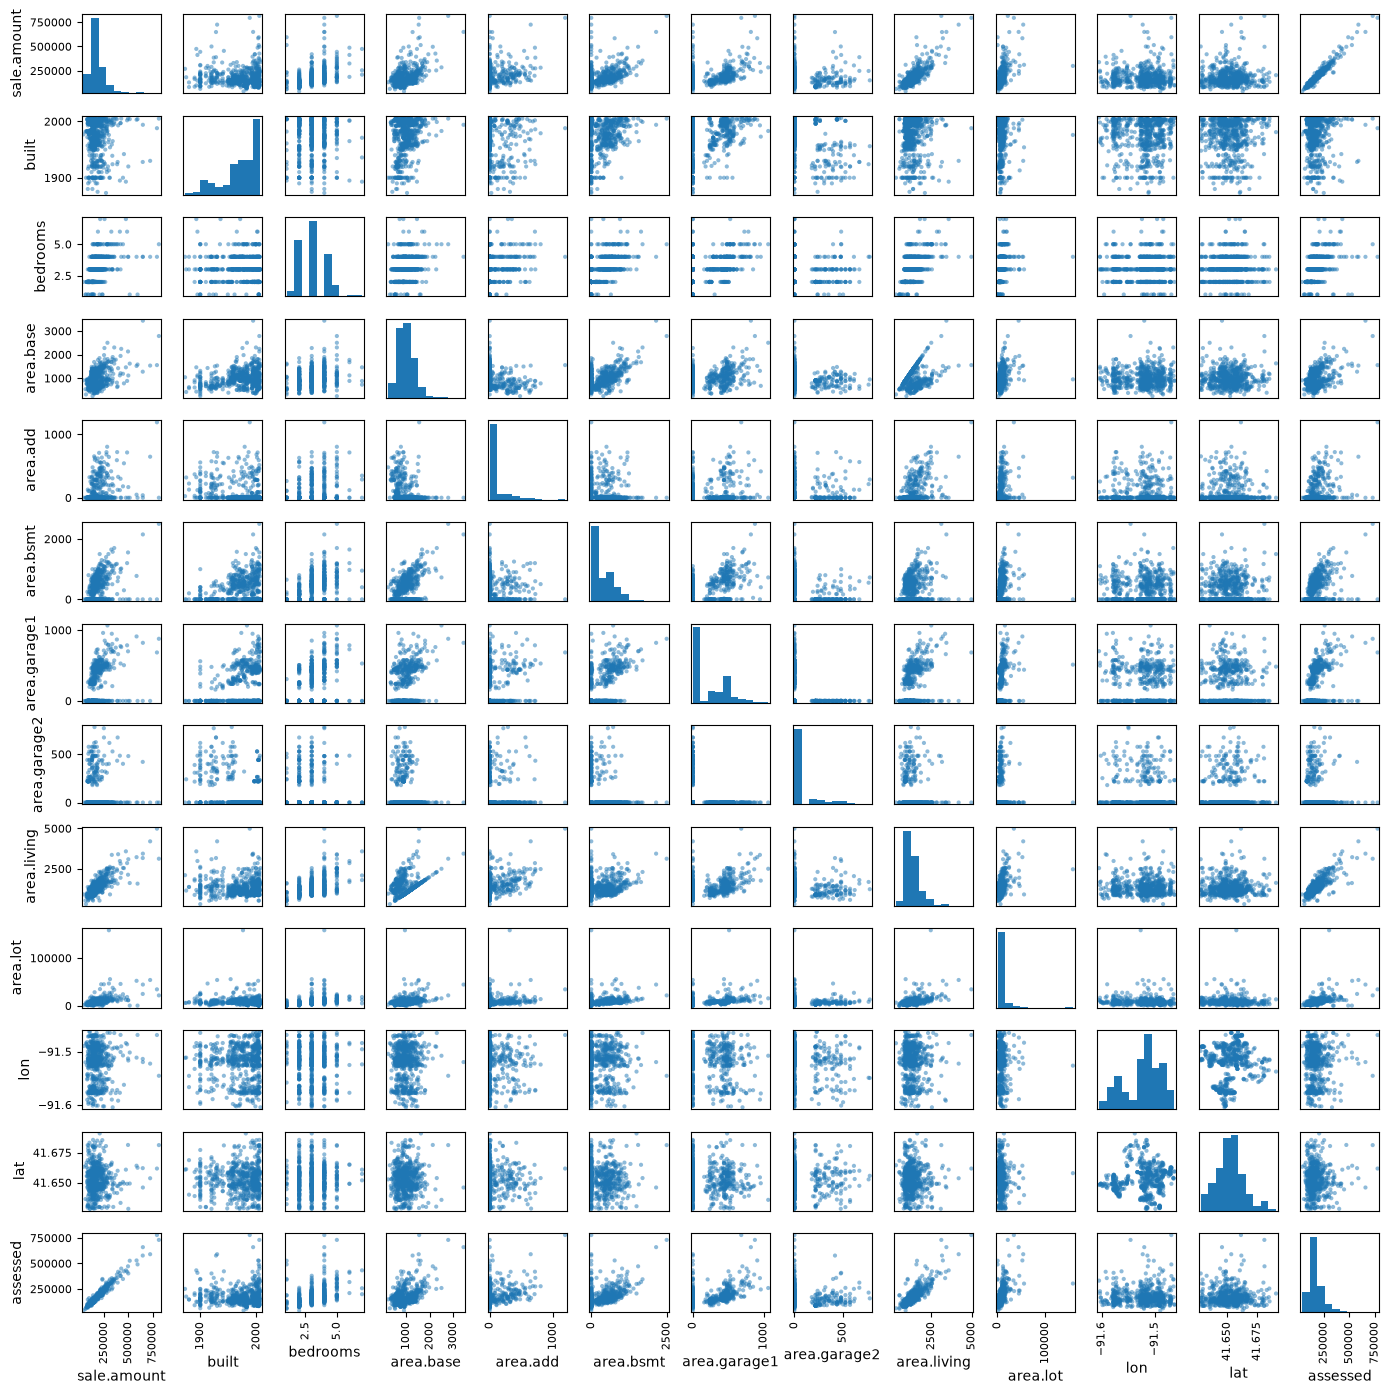

In [11]:
from pandas.plotting import scatter_matrix

## Create the scatterplot matrix after selecting only numeric columns
plot = scatter_matrix(ic_train.select_dtypes(include=['number']), figsize=(14, 14))
plt.tight_layout()
plt.show()

**Comment:** `area.living` and `assessed`, and maybe `area.base` and `area.living`.

## Question 2

In [12]:
## Import and instantiate
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=10,weights='uniform',p=2)

## Fit using the training data
ic_train_y = ic_train['sale.amount']
ic_train_X = ic_train.select_dtypes("number").drop('sale.amount', axis=1)
knn_model.fit(ic_train_X, ic_train_y)

## Evaluate on the test data
from sklearn.metrics import root_mean_squared_error
ic_test_X = ic_test.select_dtypes("number").drop('sale.amount', axis=1) ## Create X for the test set
ic_test_y = ic_test['sale.amount']
root_mean_squared_error(ic_test_y, knn_model.predict(ic_test_X)) ## Calculate RMSE w/ test data

24086.67584498422

### Part A

In [13]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_model = DecisionTreeRegressor(max_depth=3)
decision_tree_model.fit(ic_train_X, ic_train_y)
root_mean_squared_error(ic_test_y, decision_tree_model.predict(ic_test_X)) ## Calculate RMSE w/ test data

30461.27585926213

### Part B

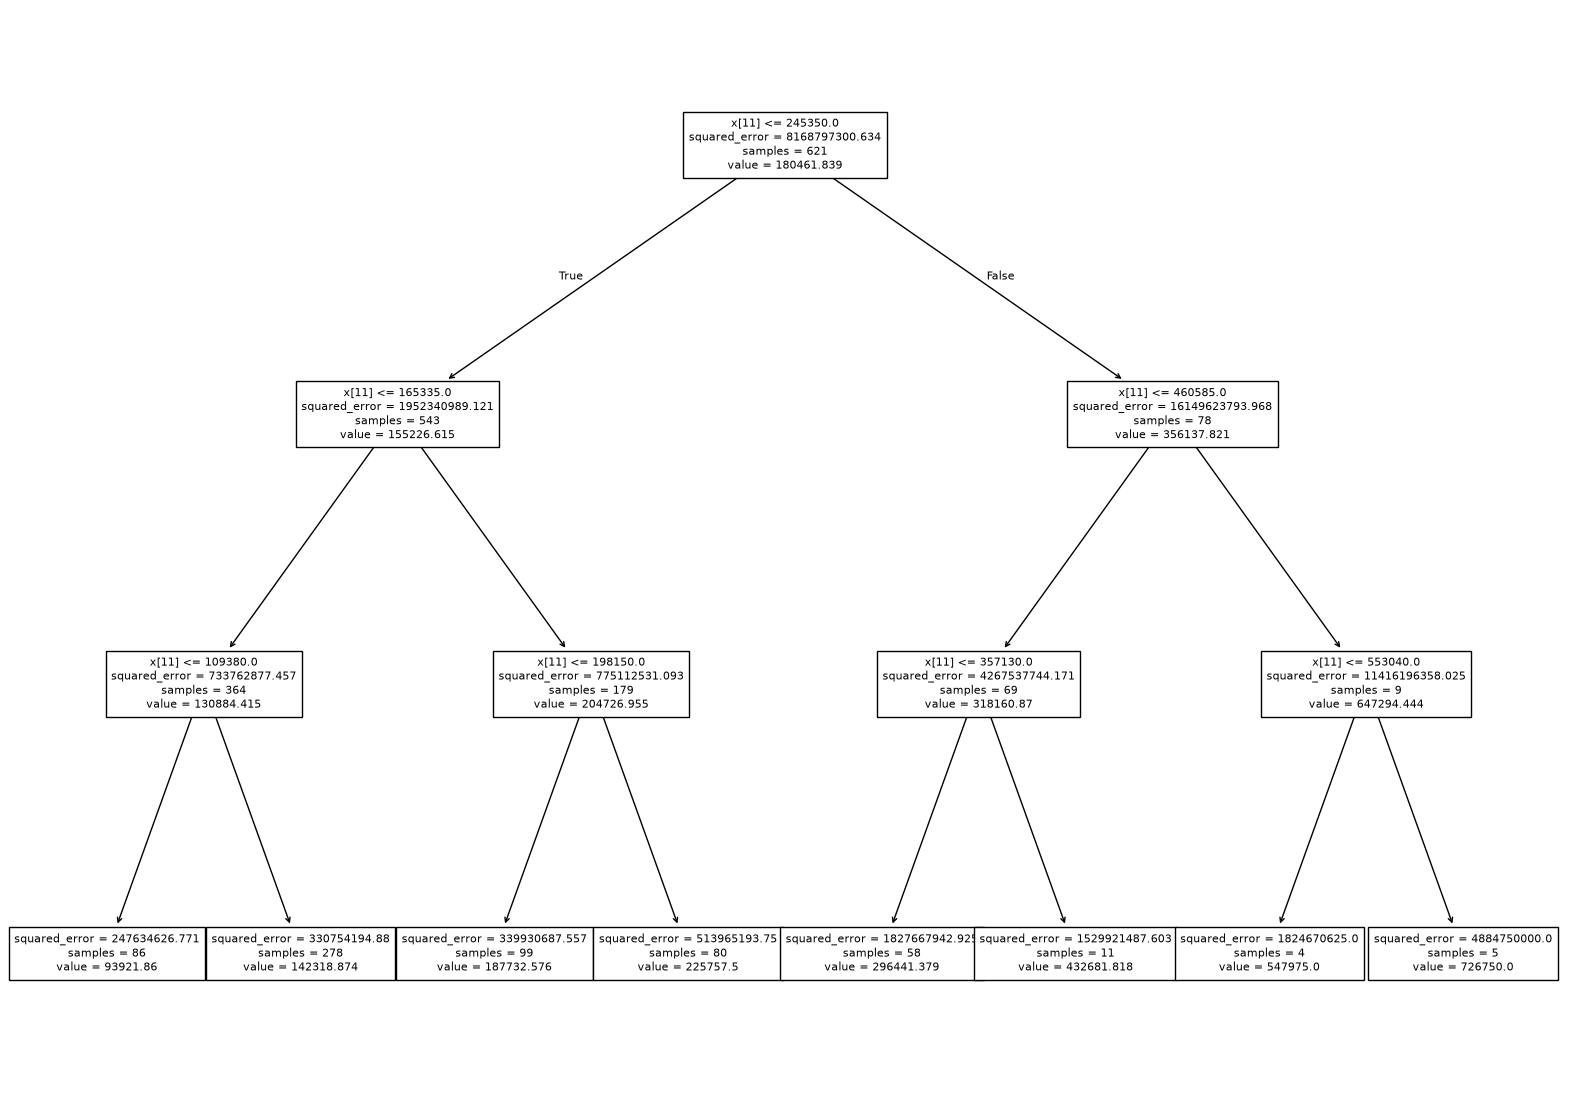

In [14]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,14))
plot_tree(decision_tree_model, fontsize=8)
plt.show()

### Part C

**Comment:** For the house priced at $185k, the Decision Tree predicted it at about $177k. We just follow the tree, assessing where the value falls into True or False, and trace accordingly.

### Part D

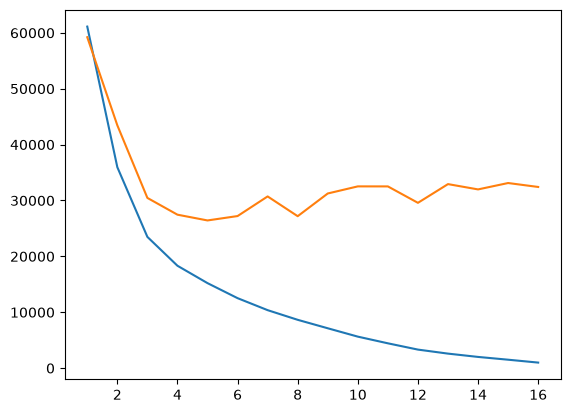

In [15]:
train_rmses = []
test_rmses = []
depth_range = range(1, 16 + 1)  # 1 -> 16
for i in depth_range:
    dtm = DecisionTreeRegressor(max_depth=i, random_state=7)
    dtm.fit(ic_train_X, ic_train_y)
    
    train_rmse = root_mean_squared_error(ic_train_y, dtm.predict(ic_train_X))
    test_rmse = root_mean_squared_error(ic_test_y, dtm.predict(ic_test_X))
    
    train_rmses.append(train_rmse)
    test_rmses.append(test_rmse)

plt.plot(depth_range, train_rmses)
plt.plot(depth_range, test_rmses)
plt.show()

## Question 3

### Part A

**Comment:** I wouldn't recommend this approach because `fit_Transform()` to **all** of our data, including future test data, leading to data leakage. This method should only be used during the exploratory analysis of the training data.

### Part B

In [16]:
from sklearn.preprocessing import StandardScaler

# rescale training and testing data
standard_scaler = StandardScaler().fit(ic_train_X)  # fit: compute the mean and std used later for scaling
train_X_scaled = standard_scaler.transform(ic_train_X)  # transform: perform standardization by centering and scaling
test_X_scaled = standard_scaler.transform(ic_test_X)

# do KNN regression to predict y
knn_model_2 = KNeighborsRegressor(n_neighbors=5, weights='uniform', p=2)  # p=2 means Euclidean distance
knn_model_2.fit(train_X_scaled, ic_train_y)
# report rmse on test data
root_mean_squared_error(ic_test_y, knn_model_2.predict(test_X_scaled))

44759.76200241486

**Comment:** The unscaled RMSE was roughly $24086$, which is almost half of the scaled RMSE (about $44759$). Since the RMSE increased, the scaling did not lead to better performance. This is surprising but can be explained if we look back at the plots we drawn previously when we explore the predictors. Variables that have large original scales while also having a strong relationship with `sale.amount` like `assessed` were probably having a lot of influence on the KNN distance calculation. After scaling, we gave all the predictors the same scale, and so many variables that don't have as much predictive power, like `lon` or `lat` now got more influence on the KNN model outcome, which can cause KNN to select less useful neighbors. Hence, the test RSME increased.

## Question 4

I would **not** expect so because unlike KNN, Decision Trees are scale-invariant. The scale of shape of the variables does not affect how Decision Trees make splits. They make splits based on thresholds and orders so Decision Trees can make splits prior to and after any scaling, including quantile transformation.

## Question 5

In [35]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# variable is "yes" if a home's assessed value is greater than its sale price and "no" otherwise
ic_train['over_assessed'] = np.where(
    ic_train['assessed'] > ic_train['sale.amount'],
    "yes",
    "no"
)
ic_test['over_assessed'] = np.where(
    ic_test['assessed'] > ic_test['sale.amount'],
    "yes",
    "no"
)

knn_model_3 = KNeighborsClassifier(n_neighbors=10,weights='distance',p=2)

# Select data
ic_train_y_3 = ic_train['over_assessed']
ic_train_X_3 = ic_train.select_dtypes("number").drop(['sale.amount', 'assessed'], axis=1)
ic_test_X_3 = ic_test.select_dtypes("number").drop(['sale.amount', 'assessed'], axis=1) ## Create X for the test set
ic_test_y_3 = ic_test['over_assessed']

# Quantile transform

qt_trans = QuantileTransformer(n_quantiles=len(ic_train_X_3)).fit(ic_train_X_3)
ic_train_X_3 = qt_trans.transform(ic_train_X_3)
ic_test_X_3 = qt_trans.transform(ic_test_X_3)

# Fit
knn_model_3.fit(ic_train_X_3, ic_train_y_3)

# Accuracy
accuracy_score(ic_test_y_3, knn_model_3.predict(ic_test_X_3))

0.5961538461538461

**Comment:** The model's accuracy is about $59.6\%$. 

## Question 6

In [39]:
from sklearn.preprocessing import OneHotEncoder

# Data selction and one hot encoder
ic_train_X_extra = ic_train[['style', 'ac']]
ic_test_X_extra = ic_test[['style', 'ac']]
oh_trans_train = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(ic_train_X_extra)

# Transform
ic_train_X_extra_ohe = oh_trans_train.transform(ic_train_X_extra)
ic_test_X_extra_ohe = oh_trans_train.transform(ic_test_X_extra)

# Concatenate these columns into the previous dataframes
ic_train_X_4 = np.concatenate([ic_train_X_3, np.asarray(ic_train_X_extra_ohe)], axis=1)
ic_test_X_4 = np.concatenate([ic_test_X_3, np.asarray(ic_test_X_extra_ohe)], axis=1)

# Fit
knn_model_4 = KNeighborsClassifier(n_neighbors=10,weights='distance',p=2)
knn_model_4.fit(ic_train_X_4, ic_train_y_3)

# Accuracy
accuracy_score(ic_test_y_3, knn_model_4.predict(ic_test_X_4))

0.6025641025641025

**Comment:** The accuracy went up from about $59.6\%$ to $60.3\%$, which is a very small improvement so it didn't add much predictive power.